In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../'))
# 导入qteasy模块
import qteasy as qt
print(f'qteasy version: {qt.__version__}, datasource: {qt.QT_DATA_SOURCE}')

op = qt.Operator(strategies = 'ndayrate', signal_type='pt')

qteasy version: 2.0.0, datasource: mysql://localhost@3306/ts_db


In [2]:
op.set_parameter(0,   
                 run_freq='d',  # 策略的选股周期为每日选股 
                 sort_ascending=False,  # 设置选择涨幅最大的指数
                 max_sel_count=0.5,  # 设置每次选择一只指数后续持有
                 par_values=(20, ),  # 策略参数N=20，比较20日涨幅
                 data_types='close',  # 使用收盘价计算涨幅
                 condition='greater',
                 ubound=0.0
                )

TypeError: pars is invalid! (close)

In [24]:
qt.configure(asset_pool=['000300.SH',
                         '399006.SZ'],  # 投资指数包括沪深300和创业板指数
             invest_cash_amounts=[1000000],  # 投入金额为十万元
             asset_type='IDX',  # 为简单起见，直接投资于指数
             cost_rate_buy=0.0001,  # 买入资产时交易费用万分之一
             cost_rate_sell=0.0001,  # 卖出资产时的交易费用为万分之一
             invest_start='20110101',  # 模拟交易开始日期
             invest_end='20201231',  # 模拟交易结束日期
             trade_batch_size=100,  # 买入资产时最小交易批量
             sell_batch_size=0,  # 卖出资产时最小交易批量
             PT_signal_timing='aggressive')  


     |                                  |
     |       BACK TESTING RESULT        |
     |                                  |

qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 65.5ms
time consumption for operation back looping:  820.0ms

investment starts on      2011-01-04 00:00:00
ends on                   2020-12-31 00:00:00
Total looped periods:     10.0 years.

-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary

          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000300.SH    84       84    168   24.5%      0.0%     75.5%  
399006.SZ    91      115    206   41.8%      0.0%     58.2%   

Total operation fee:     ¥   74,405.90
total investment amount: ¥1,000,000.00
final value:              ¥6,248,679.35
Total return:                   524.87% 
Avg Yearly return:               20.12%
Skewness:                         -0.40
Kurtosis:    

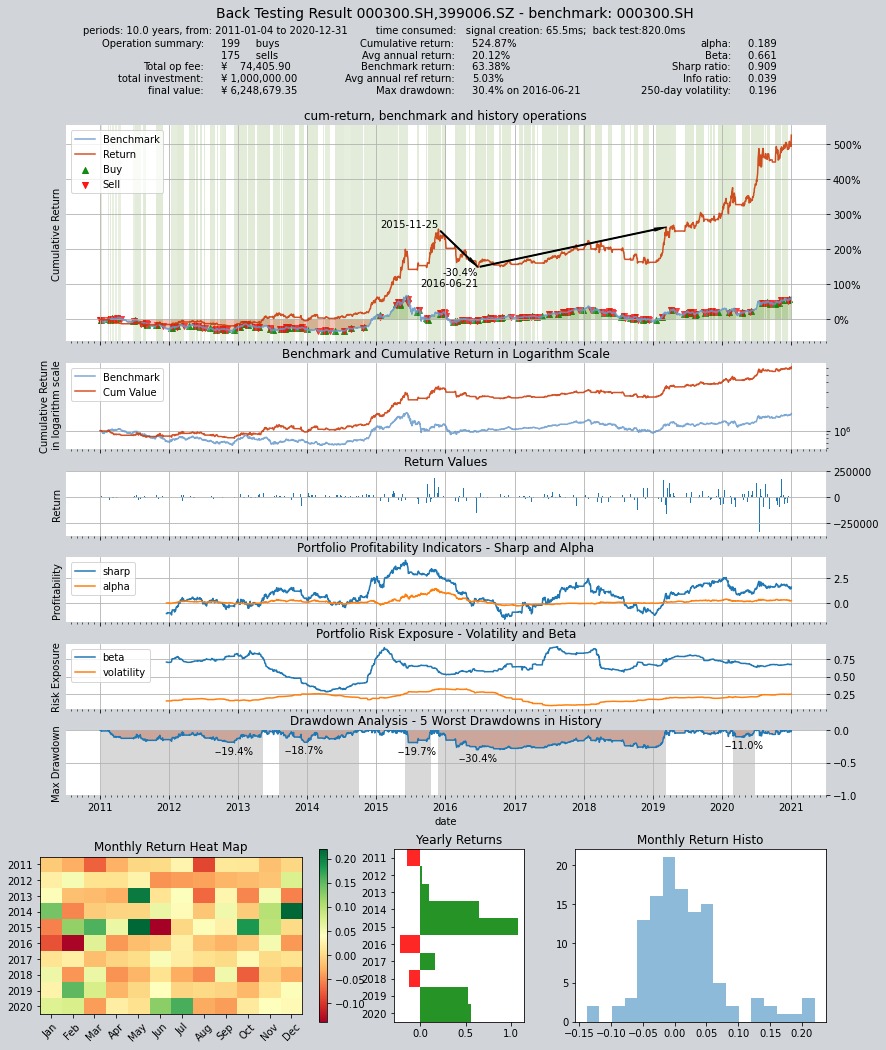

In [25]:
res=qt.run(op, visual=True, trade_log=True)

In [4]:
qt.configuration(up_to=5)

No. Config-Key            Cur Val        Default val
----------------------------------------------------
1   mode                  1              <1>
2   asset_pool            ['000300.SH', '399006.SZ']<000300.SH>
3   asset_type            IDX            <IDX>
4   trade_batch_size      1              <0.0>
5   sell_batch_size       0              <0.0>
6   riskfree_ir           0.0035         <0.0035>
7   parallel              True           <True>
8   hist_dnld_parallel    16             <16>
9   hist_dnld_delay       0.0            <0.0>
10  hist_dnld_delay_evy   0              <0>
11  hist_dnld_prog_bar    False          <False>
12  hist_dnld_retry_cnt   7              <7>
13  hist_dnld_retry_delay 1.0            <1.0>
14  hist_dnld_backoff     2.0            <2.0>
15  gpu                   False          <False>
16  local_data_source     database       <file>
17  local_data_file_type  csv            <csv>
18  local_data_file_path  qteasy/data/   <qteasy/data/>
19  local_db_host   

In [30]:
op = qt.Operator(strategies='ndayrate', signal_type='pt')
op.set_parameter(0, 
                 strategy_run_freq='d',
                 sort_ascending=False,
                 pars=(21, ),
                 data_types='close',
                 max_sel_count=0.5,
                 condition='greater',  # 新增过滤条件：20日涨幅大于等于
                 ubound=-0.0005  # 过滤条件值：0
                )

qt.configure(asset_pool=['000300.SH',
                                            '399006.SZ'],  # 投资指数包括沪深300和创业板指数
             asset_type='IDX',  # 为简单起见，直接投资于指数
             cost_rate_buy=0.0000,  # 买入资产时交易费用万分之一
             cost_rate_sell=0.0000,  # 卖出资产时的交易费用为万分之一
             invest_start='20110101',  # 模拟交易开始日期
             invest_end='20201231',  # 模拟交易结束日期
             trade_batch_size=1,  # 买入资产时最小交易批量
             sell_batch_size=0,  # 卖出资产时最小交易批量
             maximize_cash_usage=True,
             stock_deliver_period=0,
             long_position_limit=2.0
            )


     |                                  |
     |       BACK TESTING RESULT        |
     |                                  |

qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 63.2ms
time consumption for operation back looping:  757.8ms

investment starts on      2011-01-04 00:00:00
ends on                   2020-12-31 00:00:00
Total looped periods:     10.0 years.

-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary

          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000300.SH   101      101    202   25.4%      0.0%     74.6%  
399006.SZ    98       99    197   42.9%      0.0%     57.1%   

Total operation fee:     ¥    1,000.00
total investment amount: ¥  100,000.00
final value:              ¥  731,873.49
Total return:                   631.87% 
Avg Yearly return:               22.03%
Skewness:                         -0.36
Kurtosis:    

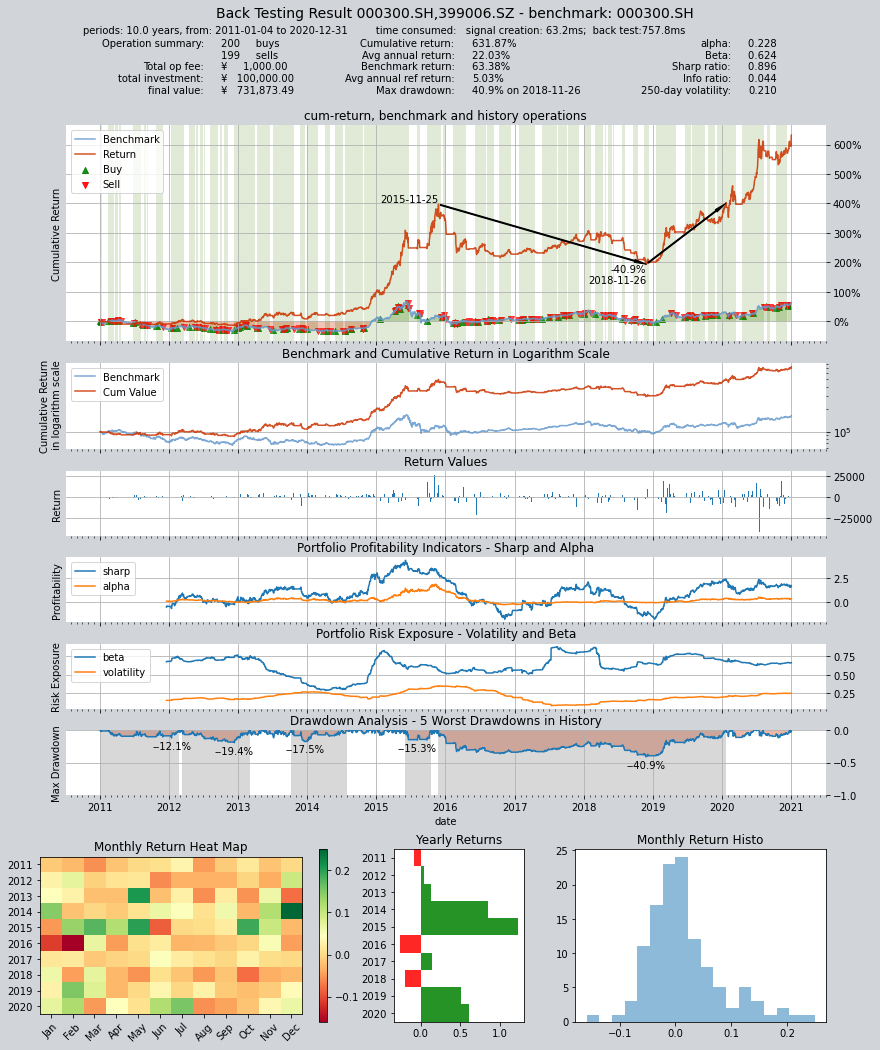

In [31]:
res=qt.run(op, visual=True, trade_log=True)